# 02 — Instability Index & EDA
## Layer 1: Composite Macroeconomic Instability Index

### Purpose
Construct country-year instability index from z-scores,
rolling volatility, and shock components. Validate against
known crisis events. Run full EDA on target, features,
index, and crisis flag.

### Input
- `../data/02_panel_features.csv`

### Output
- `../data/03_panel_instability.csv`
- 4 EDA plot PNGs

### Run after → Run before
`01_feature_engineering.ipynb` → `03_layer2a_econometric.ipynb`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import MinMaxScaler, RobustScaler
from scipy.stats import mstats
import warnings
warnings.filterwarnings("ignore")
df_panel = pd.read_csv("data/02_panel_features.csv")
TRAIN_END = 2019
train_mask = df_panel["YEAR"] <= TRAIN_END

instability_indicators = [
    "Inflation", "GDP_Growth", "Fiscal_Balance", "Debt", "Current_Account"
]

for col in instability_indicators:
    stats_by_country = (
        df_panel.loc[train_mask]
        .groupby("COUNTRY")[col]
        .agg(["mean", "std"])
        .rename(columns={"mean": f"{col}_train_mean", "std": f"{col}_train_std"})
    )
    df_panel = df_panel.merge(stats_by_country, on="COUNTRY", how="left")
    global_mean = df_panel.loc[train_mask, col].mean()
    global_std = df_panel.loc[train_mask, col].std()
    mu = df_panel[f"{col}_train_mean"].fillna(global_mean)
    sigma = df_panel[f"{col}_train_std"].replace(0, np.nan).fillna(global_std)
    df_panel[f"{col}_zscore"] = (df_panel[col] - mu) / (sigma + 1e-8)

for col in instability_indicators:
    df_panel[f"{col}_shock"] = (
        df_panel.groupby("COUNTRY")[col].diff().abs()
    )

volatility_cols = [f"{col}_rollstd3" for col in instability_indicators]
zscore_cols = [f"{col}_zscore" for col in instability_indicators]
shock_cols = [f"{col}_shock" for col in instability_indicators]
all_comp_cols = zscore_cols + volatility_cols + shock_cols

for col in all_comp_cols:
    df_panel[col] = mstats.winsorize(df_panel[col].fillna(0), limits=[0.05, 0.05])

robust_scaler = RobustScaler()
minmax_scaler = MinMaxScaler(feature_range=(0, 100))

df_panel.loc[train_mask, all_comp_cols] = robust_scaler.fit_transform(
    df_panel.loc[train_mask, all_comp_cols]
)
df_panel.loc[~train_mask, all_comp_cols] = robust_scaler.transform(
    df_panel.loc[~train_mask, all_comp_cols]
)
df_panel[all_comp_cols] = df_panel[all_comp_cols].clip(0, 1)

df_panel["z_component"] = df_panel[zscore_cols].abs().mean(axis=1)
df_panel["vol_component"] = df_panel[volatility_cols].mean(axis=1)
df_panel["shock_component"] = df_panel[shock_cols].mean(axis=1)

raw_index = (
    0.30 * df_panel["z_component"]
    + 0.40 * df_panel["vol_component"]
    + 0.30 * df_panel["shock_component"]
)

df_panel.loc[train_mask, "Instability_Index"] = minmax_scaler.fit_transform(
    raw_index.loc[train_mask].to_frame()
)
df_panel.loc[~train_mask, "Instability_Index"] = minmax_scaler.transform(
    raw_index.loc[~train_mask].to_frame()
)

df_panel["Instability_Index"] = df_panel["Instability_Index"].clip(0, 100)
df_panel["Instability_Index_lag1"] = (
    df_panel.sort_values(["COUNTRY", "YEAR"])
    .groupby("COUNTRY")["Instability_Index"]
    .shift(1)
)

In [2]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# from scipy import stats
# from sklearn.preprocessing import MinMaxScaler, RobustScaler
# from scipy.stats import mstats
# import warnings
# warnings.filterwarnings("ignore")

# df_panel = pd.read_csv("data/02_panel_features.csv")
# print(f"Loaded: {df_panel.shape} | Countries: {df_panel['COUNTRY'].nunique()}")

In [3]:
# # ── Instability indicators ────────────────────────────────────
# instability_indicators = [
#     "Inflation","GDP_Growth","Fiscal_Balance",
#     "Debt","Current_Account"
# ]

# # Component 1: Z-score (within-country deviation)
# for col in instability_indicators:
#     df_panel[f"{col}_zscore"] = df_panel.groupby("COUNTRY")[col]        .transform(lambda x: (x - x.mean()) / (x.std() + 1e-8))

# # Component 2: Volatility (rolling 3yr std) — already computed
# volatility_cols = [f"{col}_rollstd3" for col in instability_indicators]

# # Component 3: Shock (absolute year-on-year change)
# for col in instability_indicators:
#     df_panel[f"{col}_shock"] = df_panel.groupby("COUNTRY")[col]        .transform(lambda x: x.diff().abs())

# zscore_cols  = [f"{col}_zscore" for col in instability_indicators]
# shock_cols   = [f"{col}_shock"  for col in instability_indicators]
# all_comp_cols= zscore_cols + volatility_cols + shock_cols

# print(f"Component columns: {len(all_comp_cols)}")

In [4]:
# # ── Winsorize + RobustScaler ──────────────────────────────────
# for col in all_comp_cols:
#     arr = df_panel[col].fillna(0).values
#     df_panel[col] = mstats.winsorize(arr, limits=[0.05, 0.05])

# scaler = RobustScaler()
# df_panel[all_comp_cols] = scaler.fit_transform(df_panel[all_comp_cols])
# df_panel[all_comp_cols] = df_panel[all_comp_cols].clip(0, 1)

# # ── Composite index ───────────────────────────────────────────
# df_panel["z_component"]     = df_panel[zscore_cols].abs().mean(axis=1)
# df_panel["vol_component"]   = df_panel[volatility_cols].mean(axis=1)
# df_panel["shock_component"] = df_panel[shock_cols].mean(axis=1)

# w1, w2, w3 = 0.30, 0.40, 0.30
# df_panel["Instability_Index"] = (
#     w1 * df_panel["z_component"] +
#     w2 * df_panel["vol_component"] +
#     w3 * df_panel["shock_component"]
# )

# df_panel["Instability_Index"] = MinMaxScaler(feature_range=(0,100))    .fit_transform(df_panel[["Instability_Index"]])

# print(df_panel["Instability_Index"].describe().round(2))

In [5]:
# df_panel = df_panel.sort_values(["COUNTRY", "YEAR"])

# df_panel["Instability_Index_lag1"] = (
#     df_panel.groupby("COUNTRY")["Instability_Index"]
#     .shift(1)
# )

In [6]:
# # ── Stability categories (percentile-based) ───────────────────
# p20 = df_panel["Instability_Index"].quantile(0.20)
# p50 = df_panel["Instability_Index"].quantile(0.50)
# p80 = df_panel["Instability_Index"].quantile(0.80)

# df_panel["Stability_Category"] = pd.cut(
#     df_panel["Instability_Index"],
#     bins=[0, p20, p50, p80, 100],
#     labels=["Stable","Moderate","Unstable","Crisis"],
#     include_lowest=True
# )
# df_panel["Crisis_Flag"] = (
#     df_panel["Stability_Category"] == "Crisis"
# ).astype(int)

# print(df_panel["Stability_Category"].value_counts())
# print(f"Crisis rate: {df_panel['Crisis_Flag'].mean()*100:.1f}%")

In [7]:
# # ── Validation against known crisis events ────────────────────
# validation_cases = [
#     ("Greece",                             2010),
#     ("Argentina",                          2001),
#     ("United States",                      2009),
#     ("Ireland",                            2010),
#     ("Venezuela, República Bolivariana de",2016),
# ]
# print("=== Validation: known crisis years ===")
# for country, year in validation_cases:
#     row = df_panel[
#         (df_panel["COUNTRY"]==country) &
#         (df_panel["YEAR"]==year)
#     ]["Instability_Index"]
#     val = f"{row.values[0]:.1f}/100" if not row.empty else "not in panel"
#     print(f"{country} {year}: {val}")

# print("=== Top 15 most unstable country-years ===")
# print(df_panel[["COUNTRY","YEAR","Instability_Index"]]
#       .sort_values("Instability_Index", ascending=False)
#       .head(15).to_string(index=False))

In [8]:
# ============================================================
# Stability categories and crisis flag
# ============================================================

p20 = df_panel["Instability_Index"].quantile(0.20)
p50 = df_panel["Instability_Index"].quantile(0.50)
p80 = df_panel["Instability_Index"].quantile(0.80)

df_panel["Stability_Category"] = pd.cut(
    df_panel["Instability_Index"],
    bins=[-np.inf, p20, p50, p80, np.inf],
    labels=[
        "Stable",
        "Moderate",
        "Unstable",
        "Crisis",
    ],
    include_lowest=True,
)

df_panel["Crisis_Flag"] = (
    df_panel["Stability_Category"] == "Crisis"
).astype(int)

print(df_panel["Stability_Category"].value_counts())
print(
    f"Crisis rate: {df_panel['Crisis_Flag'].mean() * 100:.2f}%"
)

Stability_Category
Moderate    1547
Unstable    1546
Stable      1032
Crisis      1032
Name: count, dtype: int64
Crisis rate: 20.01%


In [9]:
# ── Save checkpoint ───────────────────────────────────────────
df_panel.to_csv("data/03_panel_instability.csv", index=False)
print("Saved: data/03_panel_instability.csv")
print(df_panel.shape)

Saved: data/03_panel_instability.csv
(5157, 116)


In [10]:
print(
    df_panel[
        ["COUNTRY", "YEAR", "Instability_Index", "Instability_Index_lag1"]
    ].head(10)
)

                            COUNTRY  YEAR  Instability_Index  \
0  Afghanistan, Islamic Republic of  2005          55.945200   
1  Afghanistan, Islamic Republic of  2006          71.694807   
2  Afghanistan, Islamic Republic of  2007          77.973963   
3  Afghanistan, Islamic Republic of  2008          63.353291   
4  Afghanistan, Islamic Republic of  2009          71.226179   
5  Afghanistan, Islamic Republic of  2010          70.130281   
6  Afghanistan, Islamic Republic of  2011          60.599051   
7  Afghanistan, Islamic Republic of  2012          65.471695   
8  Afghanistan, Islamic Republic of  2013          43.431465   
9  Afghanistan, Islamic Republic of  2014          36.429149   

   Instability_Index_lag1  
0                     NaN  
1               55.945200  
2               71.694807  
3               77.973963  
4               63.353291  
5               71.226179  
6               70.130281  
7               60.599051  
8               65.471695  
9              

In [11]:

 
lag_feature_cols = [
    "Inflation_lag1", "Exports_lag1", "Imports_lag1",
    "Fiscal_Balance_lag1", "Current_Account_lag1",
    "Debt_diff_lag1", "Expenditure_diff_lag1", "Revenue_diff_lag1",
    "Savings_diff_lag1", "Investment_diff_lag1"
]
 
# Plot style
plt.rcParams.update({
    "figure.facecolor": "#F9F9F7",
    "axes.facecolor":   "#F9F9F7",
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.grid":        True,
    "grid.color":       "#E5E5E0",
    "grid.linewidth":   0.6,
    "font.family":      "sans-serif",
    "font.size":        11,
})
BLUE   = "#2E5090"
AMBER  = "#C9720F"
RED    = "#A32D2D"
GREEN  = "#3B6D11"
TEAL   = "#0F6E56"
GRAY   = "#5F5E5A"


SECTION 1 — TARGET VARIABLE: GDP_Growth


count    5157.000
mean        3.656
std         5.737
min       -50.339
25%         1.634
50%         3.747
75%         5.852
max       147.973
Name: GDP_Growth, dtype: float64

Skewness : 4.959
Kurtosis : 119.915

Top 10 GDP Growth (highest):
                       COUNTRY  YEAR  GDP_Growth
Equatorial Guinea, Republic of  1997     147.973
Equatorial Guinea, Republic of  2000     110.505
                         Libya  2012      86.827
                        Guyana  2022      63.334
Equatorial Guinea, Republic of  2001      60.023
      South Sudan, Republic of  2025      46.094
                        Guyana  2024      43.776
                        Guyana  2020      43.480
                      Maldives  2021      37.508
       Azerbaijan, Republic of  2006      34.466

Top 10 GDP Collapse (lowest):
                            COUNTRY  YEAR  GDP_Growth
                              Libya  2011     -50.339
           Central African Republic  2013     -36.392
                        

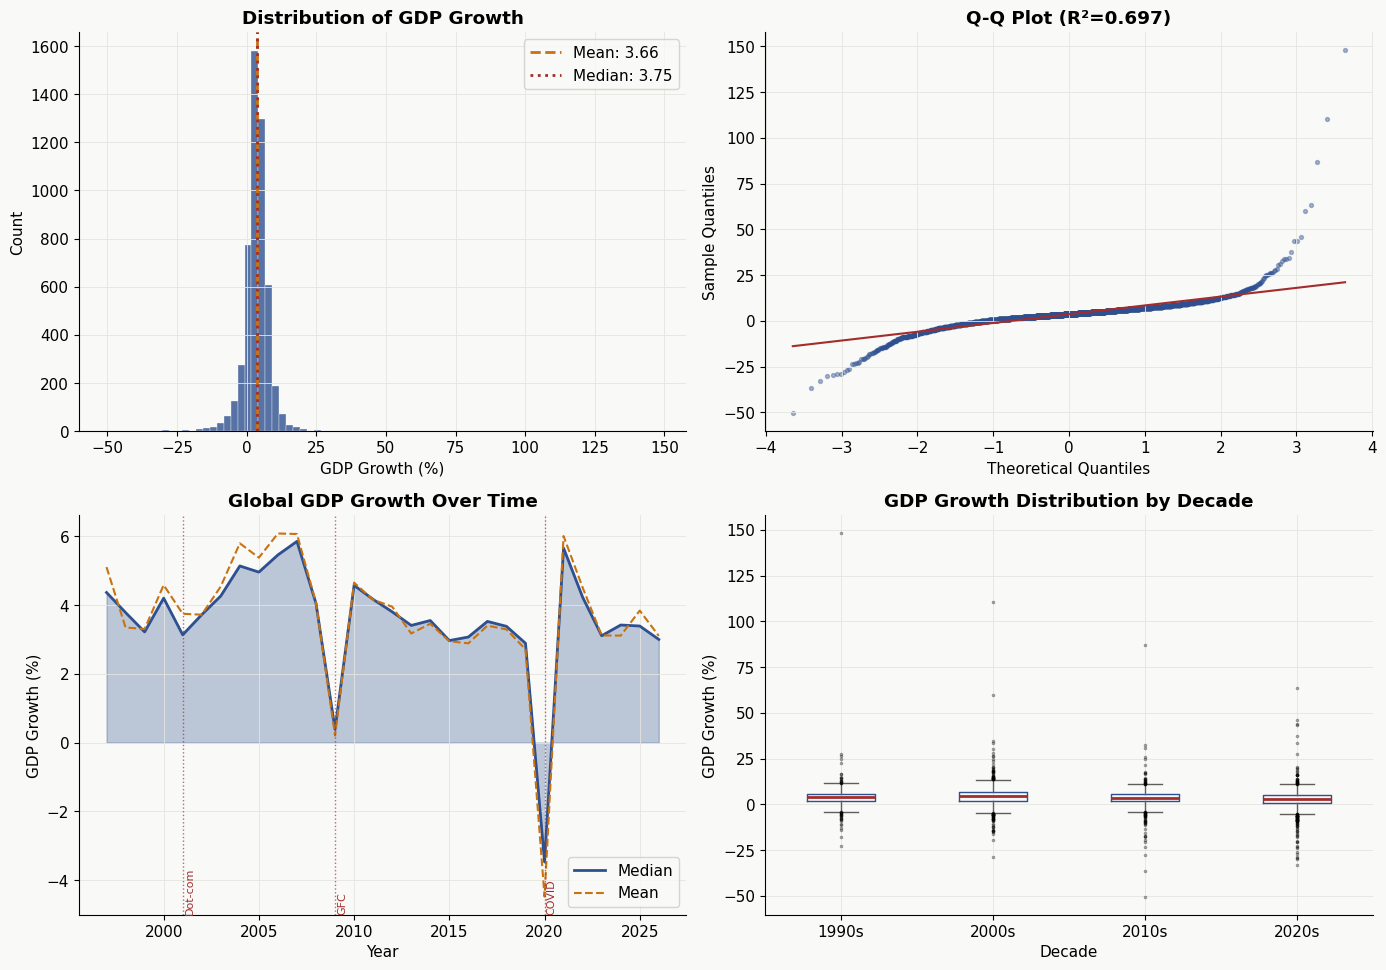

→ Saved: eda_1_gdp_growth.png

SECTION 2 — FEATURE RELATIONSHIPS WITH GDP_GROWTH

Correlation of lag features with GDP_Growth:
Expenditure_diff_lag1   -0.177
Imports_lag1             0.148
Debt_diff_lag1          -0.107
Exports_lag1             0.102
Inflation_lag1          -0.098
Savings_diff_lag1        0.056
Revenue_diff_lag1       -0.032
Investment_diff_lag1     0.030
Fiscal_Balance_lag1      0.016
Current_Account_lag1    -0.016

VIF Scores (>10 = multicollinearity concern):
              Feature VIF Flag
       Inflation_lag1 N/A     
         Exports_lag1 N/A     
         Imports_lag1 N/A     
  Fiscal_Balance_lag1 N/A     
 Current_Account_lag1 N/A     
       Debt_diff_lag1 N/A     
Expenditure_diff_lag1 N/A     
    Revenue_diff_lag1 N/A     
    Savings_diff_lag1 N/A     
 Investment_diff_lag1 N/A     


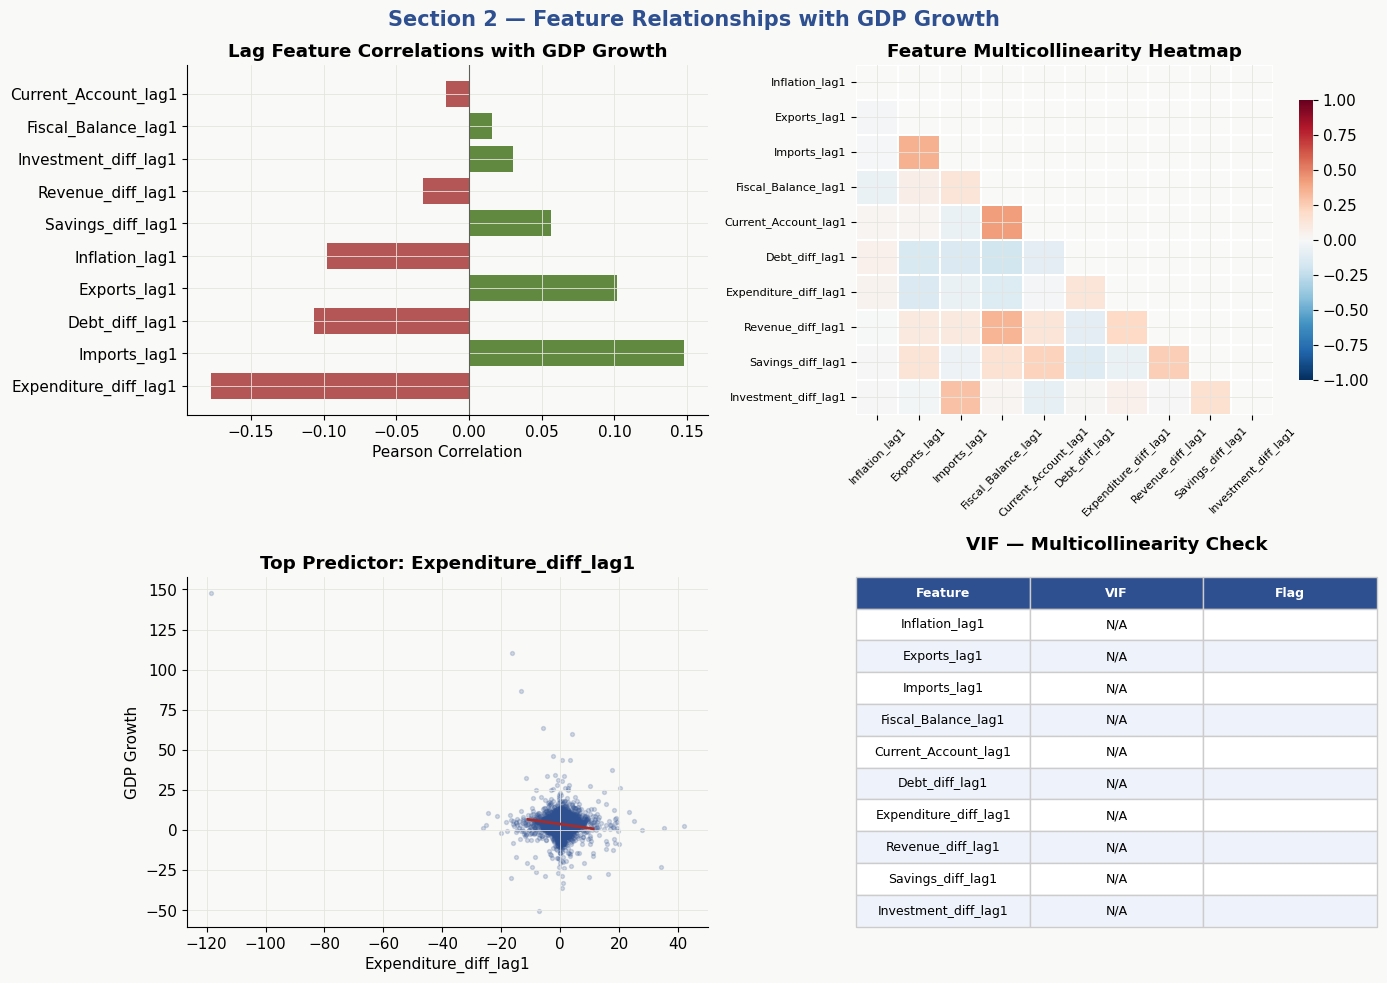

→ Saved: eda_2_features.png

SECTION 3 — INSTABILITY INDEX BEHAVIOUR
count    5157.000
mean       35.791
std        19.265
min         0.000
25%        20.165
50%        33.503
75%        48.861
max       100.000
Name: Instability_Index, dtype: float64

10 Most Stable Countries (avg index):
COUNTRY
Bangladesh                      13.98
Guatemala                       17.78
France                          18.64
Tanzania, United Republic of    19.02
Switzerland                     19.06
Korea, Republic of              19.22
China, People's Republic of     19.43
Mexico                          19.48
Australia                       19.70
Germany                         19.88

10 Most Unstable Countries (avg index):
COUNTRY
Kyrgyz Republic                        56.33
Sudan                                  57.70
Seychelles                             58.23
Congo, Republic of                     59.37
Libya                                  60.30
Suriname                               61.16
A

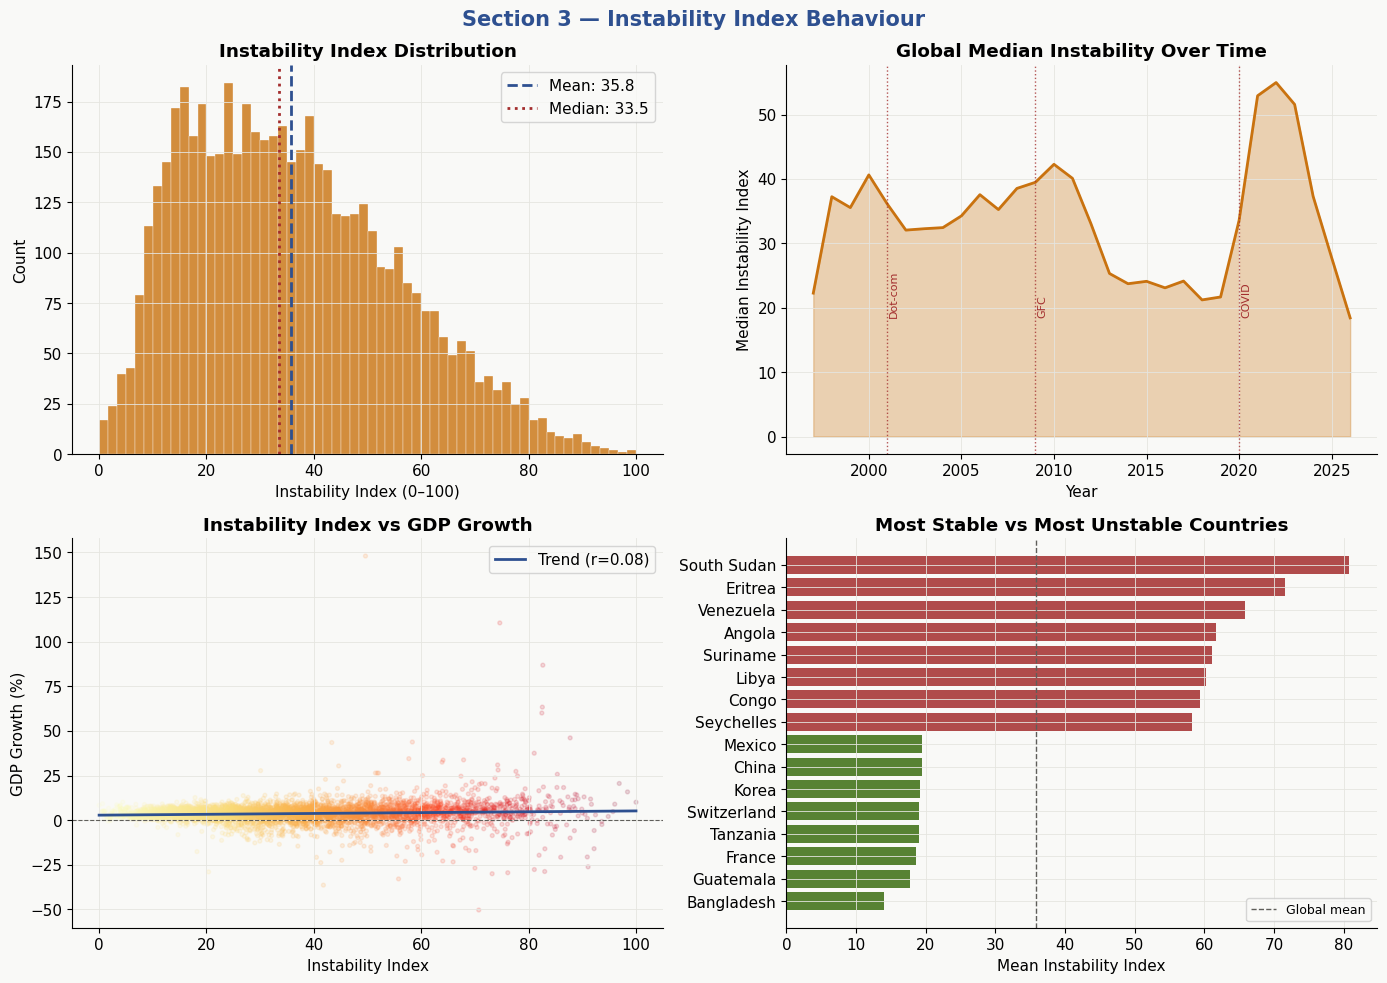

→ Saved: eda_3_instability.png

SECTION 4 — CRISIS FLAG DISTRIBUTION
Crisis_Flag
0    4125
1    1032
Name: count, dtype: int64
Crisis rate: 20.0%

Crisis rate by year (top 10 worst years):
YEAR
2022    53.2
2021    50.9
2023    46.8
2010    29.9
2009    27.0
2008    26.4
2000    25.1
2011    24.9
2001    24.4
2006    24.1

Macro profile — Crisis vs Non-Crisis:
             GDP_Growth  Inflation_lag1  Debt_diff_lag1  Fiscal_Balance_lag1  Current_Account_lag1  Instability_Index
Crisis_Flag                                                                                                          
0                  3.42            7.29            0.12                -2.05                 -2.27              28.42
1                  4.60          103.15            0.22                -2.12                 -2.19              65.26


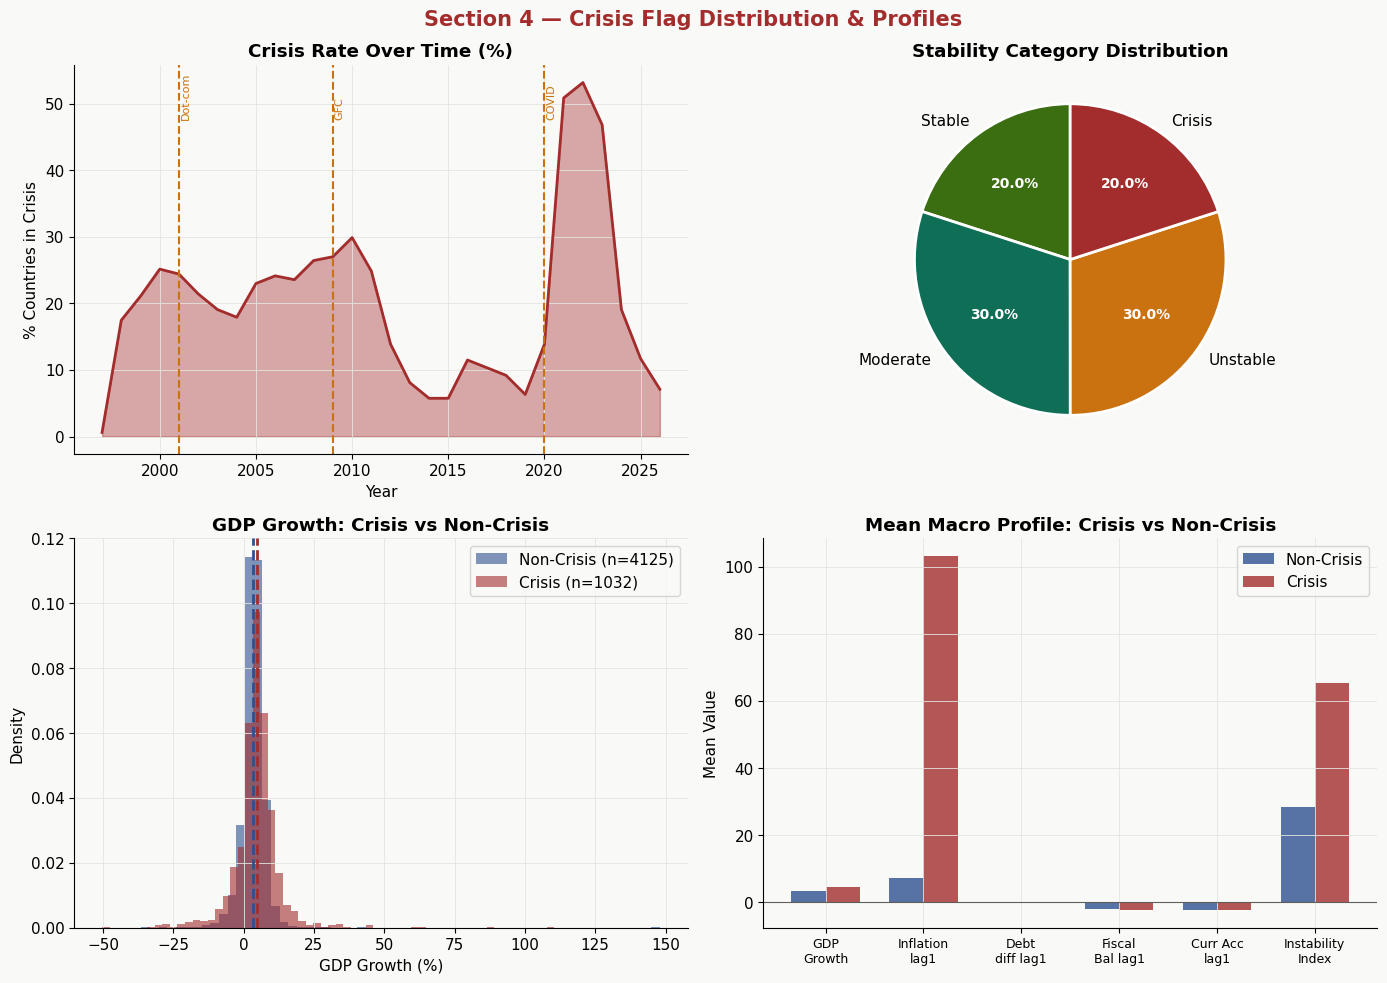

→ Saved: eda_4_crisis.png

EDA COMPLETE — KEY FINDINGS SUMMARY
Dataset shape          : (5157, 117)
Countries              : 175
Year range             : 1997 – 2026
GDP Growth — mean      : 3.66%
GDP Growth — std       : 5.74%
GDP Growth — skewness  : 4.959
Instability — mean     : 35.8
Crisis rate            : 20.0%
Instability~GDP corr   : 0.080
Strongest predictor    : Expenditure_diff_lag1 (r=0.177)
Weakest predictor      : Current_Account_lag1 (r=0.016)

Files saved:
  eda_1_gdp_growth.png
  eda_2_features.png
  eda_3_instability.png
  eda_4_crisis.png


In [12]:
import pandas as pd

# =============================================================================
# SECTION 1 — TARGET VARIABLE: GDP_Growth
# =============================================================================
print("\n" + "="*60)
print("SECTION 1 — TARGET VARIABLE: GDP_Growth")
print("="*60)
 
df_panel = pd.read_csv(r"E:\MDS\Projects\Major Project\major_project\data\03_panel_instability.csv")

print(df_panel["GDP_Growth"].describe().round(3))
print(f"\nSkewness : {df_panel['GDP_Growth'].skew():.3f}")
print(f"Kurtosis : {df_panel['GDP_Growth'].kurt():.3f}")
print(f"\nTop 10 GDP Growth (highest):")
print(df_panel[["COUNTRY","YEAR","GDP_Growth"]].nlargest(10,"GDP_Growth").to_string(index=False))
print(f"\nTop 10 GDP Collapse (lowest):")
print(df_panel[["COUNTRY","YEAR","GDP_Growth"]].nsmallest(10,"GDP_Growth").to_string(index=False))
 
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Section 1 — GDP Growth (Target Variable)", fontsize=15, fontweight="bold", color=BLUE, y=1.01)
 
# 1a — Distribution
ax = axes[0, 0]
ax.hist(df_panel["GDP_Growth"].dropna(), bins=80, color=BLUE, alpha=0.8, edgecolor="white", linewidth=0.3)
ax.axvline(df_panel["GDP_Growth"].mean(),   color=AMBER, linewidth=2, linestyle="--", label=f"Mean: {df_panel['GDP_Growth'].mean():.2f}")
ax.axvline(df_panel["GDP_Growth"].median(), color=RED,   linewidth=2, linestyle=":",  label=f"Median: {df_panel['GDP_Growth'].median():.2f}")
ax.set_title("Distribution of GDP Growth", fontweight="bold")
ax.set_xlabel("GDP Growth (%)")
ax.set_ylabel("Count")
ax.legend()
 
# 1b — QQ plot (normality check)
ax = axes[0, 1]
(osm, osr), (slope, intercept, r) = stats.probplot(df_panel["GDP_Growth"].dropna(), dist="norm")
ax.scatter(osm, osr, alpha=0.4, s=8, color=BLUE)
ax.plot(osm, slope * np.array(osm) + intercept, color=RED, linewidth=1.5)
ax.set_title(f"Q-Q Plot (R²={r**2:.3f})", fontweight="bold")
ax.set_xlabel("Theoretical Quantiles")
ax.set_ylabel("Sample Quantiles")
 
# 1c — Global median GDP growth over time
ax = axes[1, 0]
time_series = df_panel.groupby("YEAR")["GDP_Growth"].agg(["median","mean"])
ax.fill_between(time_series.index, time_series["median"], alpha=0.3, color=BLUE)
ax.plot(time_series.index, time_series["median"], color=BLUE, linewidth=2, label="Median")
ax.plot(time_series.index, time_series["mean"],   color=AMBER, linewidth=1.5, linestyle="--", label="Mean")
for yr, label in [(2001,"Dot-com"), (2009,"GFC"), (2020,"COVID")]:
    ax.axvline(yr, color=RED, linewidth=1, linestyle=":", alpha=0.7)
    ax.text(yr+0.1, ax.get_ylim()[0], label, fontsize=8, color=RED, rotation=90, va="bottom")
ax.set_title("Global GDP Growth Over Time", fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("GDP Growth (%)")
ax.legend()
 
# 1d — Box plot by decade
ax = axes[1, 1]
df_panel["Decade"] = (df_panel["YEAR"] // 10 * 10).astype(str) + "s"
decade_order = sorted(df_panel["Decade"].unique())
df_panel.boxplot(column="GDP_Growth", by="Decade", ax=ax,
                  boxprops=dict(color=BLUE), medianprops=dict(color=RED, linewidth=2),
                  whiskerprops=dict(color=GRAY), capprops=dict(color=GRAY),
                  flierprops=dict(marker=".", markersize=3, color=GRAY, alpha=0.4))
ax.set_title("GDP Growth Distribution by Decade", fontweight="bold")
ax.set_xlabel("Decade")
ax.set_ylabel("GDP Growth (%)")
plt.suptitle("")
 
plt.tight_layout()
plt.savefig("eda_1_gdp_growth.png", dpi=150, bbox_inches="tight")
plt.show()
print("→ Saved: eda_1_gdp_growth.png")
 
 
# =============================================================================
# SECTION 2 — FEATURE RELATIONSHIPS WITH GDP_GROWTH
# =============================================================================
print("\n" + "="*60)
print("SECTION 2 — FEATURE RELATIONSHIPS WITH GDP_GROWTH")
print("="*60)
 
# 2a — Correlation table
corr_with_target = df_panel[lag_feature_cols + ["GDP_Growth"]]\
    .corr()["GDP_Growth"].drop("GDP_Growth").sort_values(key=abs, ascending=False)
print("\nCorrelation of lag features with GDP_Growth:")
print(corr_with_target.round(3).to_string())
 
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Section 2 — Feature Relationships with GDP Growth", fontsize=15, fontweight="bold", color=BLUE)
 
# 2a — Correlation bar chart
ax = axes[0, 0]
colors = [GREEN if v > 0 else RED for v in corr_with_target.values]
ax.barh(corr_with_target.index, corr_with_target.values, color=colors, alpha=0.8)
ax.axvline(0, color=GRAY, linewidth=0.8)
ax.set_title("Lag Feature Correlations with GDP Growth", fontweight="bold")
ax.set_xlabel("Pearson Correlation")
 
# 2b — Correlation heatmap (full feature matrix)
ax = axes[0, 1]
corr_matrix = df_panel[lag_feature_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, ax=ax, cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, annot=False, linewidths=0.3,
            cbar_kws={"shrink": 0.8})
ax.set_title("Feature Multicollinearity Heatmap", fontweight="bold")
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.tick_params(axis="y", labelsize=8)
 
# 2c — Top 2 predictors scatter plots
ax = axes[1, 0]
top_feature = corr_with_target.abs().idxmax()
ax.scatter(df_panel[top_feature], df_panel["GDP_Growth"], alpha=0.2, s=8, color=BLUE)
m, b = np.polyfit(df_panel[top_feature].dropna(), df_panel.loc[df_panel[top_feature].notna(), "GDP_Growth"], 1)
x_line = np.linspace(df_panel[top_feature].quantile(0.01), df_panel[top_feature].quantile(0.99), 100)
ax.plot(x_line, m * x_line + b, color=RED, linewidth=2)
ax.set_title(f"Top Predictor: {top_feature}", fontweight="bold")
ax.set_xlabel(top_feature)
ax.set_ylabel("GDP Growth")
 
# 2d — VIF table (multicollinearity check)
ax = axes[1, 1]
ax.axis("off")
vif_data = df_panel[lag_feature_cols].dropna()
vif_scores = []
for i, col in enumerate(lag_feature_cols):
    try:
        vif = variance_inflation_factor(vif_data.values, i)
        vif_scores.append((col.replace("_lag1","").replace("_diff","(d)"), round(vif, 2)))
    except:
        vif_scores.append((col, "N/A"))
 
vif_df = pd.DataFrame(vif_scores, columns=["Feature", "VIF"])
vif_df["Flag"] = vif_df["VIF"].apply(lambda x: "⚠️ High" if isinstance(x, float) and x > 10 else ("✅ OK" if isinstance(x, float) else ""))
print("\nVIF Scores (>10 = multicollinearity concern):")
print(vif_df.to_string(index=False))
 
table = ax.table(
    cellText=vif_df.values,
    colLabels=vif_df.columns,
    cellLoc="center", loc="center",
    bbox=[0, 0, 1, 1]
)
table.auto_set_font_size(False)
table.set_fontsize(9)
for (r, c), cell in table.get_celld().items():
    if r == 0:
        cell.set_facecolor(BLUE)
        cell.set_text_props(color="white", fontweight="bold")
    elif r % 2 == 0:
        cell.set_facecolor("#EEF2FA")
    cell.set_edgecolor("#CCCCCC")
ax.set_title("VIF — Multicollinearity Check", fontweight="bold", pad=20)
 
plt.tight_layout()
plt.savefig("eda_2_features.png", dpi=150, bbox_inches="tight")
plt.show()
print("→ Saved: eda_2_features.png")
 
 
# =============================================================================
# SECTION 3 — INSTABILITY INDEX BEHAVIOUR
# =============================================================================
print("\n" + "="*60)
print("SECTION 3 — INSTABILITY INDEX BEHAVIOUR")
print("="*60)
 
print(df_panel["Instability_Index"].describe().round(3))
 
# Top/bottom countries by mean instability
country_instability = df_panel.groupby("COUNTRY")["Instability_Index"].mean().sort_values()
print("\n10 Most Stable Countries (avg index):")
print(country_instability.head(10).round(2).to_string())
print("\n10 Most Unstable Countries (avg index):")
print(country_instability.tail(10).round(2).to_string())
 
# Correlation: instability vs GDP_Growth
corr_inst = df_panel["Instability_Index"].corr(df_panel["GDP_Growth"])
print(f"\nCorrelation — Instability Index vs GDP_Growth: {corr_inst:.3f}")
 
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Section 3 — Instability Index Behaviour", fontsize=15, fontweight="bold", color=BLUE)
 
# 3a — Index distribution
ax = axes[0, 0]
ax.hist(df_panel["Instability_Index"], bins=60, color=AMBER, alpha=0.8, edgecolor="white", linewidth=0.3)
ax.axvline(df_panel["Instability_Index"].mean(),   color=BLUE, linewidth=2, linestyle="--", label=f"Mean: {df_panel['Instability_Index'].mean():.1f}")
ax.axvline(df_panel["Instability_Index"].median(), color=RED,  linewidth=2, linestyle=":",  label=f"Median: {df_panel['Instability_Index'].median():.1f}")
ax.set_title("Instability Index Distribution", fontweight="bold")
ax.set_xlabel("Instability Index (0–100)")
ax.set_ylabel("Count")
ax.legend()
 
# 3b — Global median instability over time
ax = axes[0, 1]
inst_time = df_panel.groupby("YEAR")["Instability_Index"].median()
ax.fill_between(inst_time.index, inst_time.values, alpha=0.3, color=AMBER)
ax.plot(inst_time.index, inst_time.values, color=AMBER, linewidth=2)
for yr, label in [(2001,"Dot-com"), (2009,"GFC"), (2020,"COVID")]:
    ax.axvline(yr, color=RED, linewidth=1, linestyle=":", alpha=0.8)
    ax.text(yr+0.1, inst_time.min(), label, fontsize=8, color=RED, rotation=90, va="bottom")
ax.set_title("Global Median Instability Over Time", fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Median Instability Index")
 
# 3c — Instability Index vs GDP_Growth scatter
ax = axes[1, 0]
scatter = ax.scatter(df_panel["Instability_Index"], df_panel["GDP_Growth"],
                     alpha=0.15, s=8, c=df_panel["Instability_Index"], cmap="YlOrRd")
m, b = np.polyfit(df_panel["Instability_Index"].dropna(),
                  df_panel.loc[df_panel["Instability_Index"].notna(), "GDP_Growth"], 1)
x_line = np.linspace(0, 100, 100)
ax.plot(x_line, m * x_line + b, color=BLUE, linewidth=2,
        label=f"Trend (r={corr_inst:.2f})")
ax.axhline(0, color=GRAY, linewidth=0.8, linestyle="--")
ax.set_title("Instability Index vs GDP Growth", fontweight="bold")
ax.set_xlabel("Instability Index")
ax.set_ylabel("GDP Growth (%)")
ax.legend()
 
# 3d — Top 15 most stable vs unstable countries
ax = axes[1, 1]
top_stable   = country_instability.head(8)
top_unstable = country_instability.tail(8)
combined = pd.concat([top_stable, top_unstable])
bar_colors = [GREEN]*8 + [RED]*8
short_names = [c.split(",")[0][:20] for c in combined.index]
ax.barh(short_names, combined.values, color=bar_colors, alpha=0.85)
ax.axvline(df_panel["Instability_Index"].mean(), color=GRAY, linewidth=1, linestyle="--", label="Global mean")
ax.set_title("Most Stable vs Most Unstable Countries", fontweight="bold")
ax.set_xlabel("Mean Instability Index")
ax.legend(fontsize=9)
 
plt.tight_layout()
plt.savefig("eda_3_instability.png", dpi=150, bbox_inches="tight")
plt.show()
print("→ Saved: eda_3_instability.png")
 
 
# =============================================================================
# SECTION 4 — CRISIS FLAG DISTRIBUTION
# =============================================================================
print("\n" + "="*60)
print("SECTION 4 — CRISIS FLAG DISTRIBUTION")
print("="*60)
 
# Ensure Crisis_Flag exists (derive from Stability_Category or Instability_Index if missing)
if "Crisis_Flag" not in df_panel.columns:
    if "Stability_Category" in df_panel.columns:
        df_panel["Crisis_Flag"] = (df_panel["Stability_Category"] == "Crisis").astype(int)
    elif "Instability_Index" in df_panel.columns:
        thresh = df_panel["Instability_Index"].quantile(0.95)
        df_panel["Crisis_Flag"] = (df_panel["Instability_Index"] >= thresh).astype(int)
        print(f"Derived Crisis_Flag using Instability_Index >= {thresh:.2f}")
    else:
        raise KeyError("Cannot derive Crisis_Flag: missing Stability_Category and Instability_Index")

print(df_panel["Crisis_Flag"].value_counts())
print(f"Crisis rate: {df_panel['Crisis_Flag'].mean()*100:.1f}%")
 
# Crisis rate by year
crisis_by_year = df_panel.groupby("YEAR")["Crisis_Flag"].mean() * 100
print("\nCrisis rate by year (top 10 worst years):")
print(crisis_by_year.sort_values(ascending=False).head(10).round(1).to_string())
 
# Macro profile — crisis vs non-crisis
profile_cols = ["GDP_Growth", "Inflation_lag1", "Debt_diff_lag1",
                "Fiscal_Balance_lag1", "Current_Account_lag1", "Instability_Index"]
print("\nMacro profile — Crisis vs Non-Crisis:")
print(df_panel.groupby("Crisis_Flag")[profile_cols].mean().round(2).to_string())
 
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Section 4 — Crisis Flag Distribution & Profiles", fontsize=15, fontweight="bold", color=RED)
 
# 4a — Crisis rate over time
ax = axes[0, 0]
ax.fill_between(crisis_by_year.index, crisis_by_year.values, alpha=0.4, color=RED)
ax.plot(crisis_by_year.index, crisis_by_year.values, color=RED, linewidth=2)
for yr, label in [(2001,"Dot-com"), (2009,"GFC"), (2020,"COVID")]:
    ax.axvline(yr, color=AMBER, linewidth=1.5, linestyle="--")
    ax.text(yr+0.1, crisis_by_year.max()*0.9, label, fontsize=8, color=AMBER, rotation=90)
ax.set_title("Crisis Rate Over Time (%)", fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("% Countries in Crisis")
 
# 4b — Category distribution pie
ax = axes[0, 1]
if "Stability_Category" in df_panel.columns:
    cat_counts = df_panel["Stability_Category"].value_counts()
else:
    bins = [-1, 25, 50, 75, 100]
    labels = ["Stable", "Moderate", "Unstable", "Crisis"]
    df_panel["Stability_Category"] = pd.cut(df_panel["Instability_Index"].fillna(-1), bins=bins, labels=labels, include_lowest=True)
    cat_counts = df_panel["Stability_Category"].value_counts()
    print("Derived Stability_Category from Instability_Index (bins):", dict(cat_counts))
cat_order  = ["Stable", "Moderate", "Unstable", "Crisis"]
cat_colors = [GREEN, TEAL, AMBER, RED]
cat_vals   = [cat_counts.get(c, 0) for c in cat_order]
wedges, texts, autotexts = ax.pie(
    cat_vals, labels=cat_order, colors=cat_colors,
    autopct="%1.1f%%", startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
for t in autotexts:
    t.set_fontsize(10)
    t.set_color("white")
    t.set_fontweight("bold")
ax.set_title("Stability Category Distribution", fontweight="bold")
 
# 4c — GDP Growth distribution: Crisis vs Non-Crisis
ax = axes[1, 0]
crisis_gdp     = df_panel[df_panel["Crisis_Flag"] == 1]["GDP_Growth"].dropna()
non_crisis_gdp = df_panel[df_panel["Crisis_Flag"] == 0]["GDP_Growth"].dropna()
ax.hist(non_crisis_gdp, bins=60, alpha=0.6, color=BLUE,  label=f"Non-Crisis (n={len(non_crisis_gdp)})", density=True)
ax.hist(crisis_gdp,     bins=60, alpha=0.6, color=RED,   label=f"Crisis (n={len(crisis_gdp)})",     density=True)
ax.axvline(non_crisis_gdp.mean(), color=BLUE, linewidth=2, linestyle="--")
ax.axvline(crisis_gdp.mean(),     color=RED,  linewidth=2, linestyle="--")
ax.set_title("GDP Growth: Crisis vs Non-Crisis", fontweight="bold")
ax.set_xlabel("GDP Growth (%)")
ax.set_ylabel("Density")
ax.legend()
 
# 4d — Macro feature means: Crisis vs Non-Crisis
ax = axes[1, 1]
profile = df_panel.groupby("Crisis_Flag")[profile_cols].mean()
x       = np.arange(len(profile_cols))
width   = 0.35
short_labels = ["GDP\nGrowth", "Inflation\nlag1", "Debt\ndiff lag1",
                "Fiscal\nBal lag1", "Curr Acc\nlag1", "Instability\nIndex"]
ax.bar(x - width/2, profile.loc[0].values, width, label="Non-Crisis", color=BLUE,  alpha=0.8)
ax.bar(x + width/2, profile.loc[1].values, width, label="Crisis",     color=RED,   alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(short_labels, fontsize=9)
ax.axhline(0, color=GRAY, linewidth=0.8)
ax.set_title("Mean Macro Profile: Crisis vs Non-Crisis", fontweight="bold")
ax.set_ylabel("Mean Value")
ax.legend()
 
plt.tight_layout()
plt.savefig("eda_4_crisis.png", dpi=150, bbox_inches="tight")
plt.show()
print("→ Saved: eda_4_crisis.png")
 
 
# =============================================================================
# SUMMARY PRINT
# =============================================================================
print("\n" + "="*60)
print("EDA COMPLETE — KEY FINDINGS SUMMARY")
print("="*60)
print(f"Dataset shape          : {df_panel.shape}")
print(f"Countries              : {df_panel['COUNTRY'].nunique()}")
print(f"Year range             : {df_panel['YEAR'].min()} – {df_panel['YEAR'].max()}")
print(f"GDP Growth — mean      : {df_panel['GDP_Growth'].mean():.2f}%")
print(f"GDP Growth — std       : {df_panel['GDP_Growth'].std():.2f}%")
print(f"GDP Growth — skewness  : {df_panel['GDP_Growth'].skew():.3f}")
print(f"Instability — mean     : {df_panel['Instability_Index'].mean():.1f}")
print(f"Crisis rate            : {df_panel['Crisis_Flag'].mean()*100:.1f}%")
print(f"Instability~GDP corr   : {corr_inst:.3f}")
print(f"Strongest predictor    : {corr_with_target.abs().idxmax()} (r={corr_with_target.abs().max():.3f})")
print(f"Weakest predictor      : {corr_with_target.abs().idxmin()} (r={corr_with_target.abs().min():.3f})")
print("\nFiles saved:")
print("  eda_1_gdp_growth.png")
print("  eda_2_features.png")
print("  eda_3_instability.png")
print("  eda_4_crisis.png")

In [13]:
# ── EDA Section 2: Feature correlations + VIF ────────────────
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

feature_cols = [
    "GDP_Growth_lag1","GDP_Growth_rollmean3","Inflation_lag1_log",
    "Exports_lag1","Imports_lag1","Fiscal_Balance_lag1",
    "Current_Account_lag1","Debt_diff_lag1","Expenditure_diff_lag1",
    "Revenue_diff_lag1","Savings_diff_lag1","Investment_diff_lag1",
    "Instability_Index"
]

corr = df_panel[feature_cols+["GDP_Growth"]].corr()["GDP_Growth"]    .drop("GDP_Growth").sort_values(key=abs,ascending=False)
print("Feature correlations with GDP_Growth:")
print(corr.round(3))

vif_data = df_panel[feature_cols].dropna()
vif_scores=[]
for i,col in enumerate(feature_cols):
    try: vif_scores.append((col,round(variance_inflation_factor(vif_data.values,i),2)))
    except: vif_scores.append((col,"N/A"))
print("\nVIF scores:")
for col,v in vif_scores: print(f"  {col}: {v}")

Feature correlations with GDP_Growth:
GDP_Growth_rollmean3     0.385
GDP_Growth_lag1          0.308
Expenditure_diff_lag1   -0.177
Imports_lag1             0.148
Debt_diff_lag1          -0.107
Exports_lag1             0.102
Instability_Index        0.080
Savings_diff_lag1        0.056
Revenue_diff_lag1       -0.032
Investment_diff_lag1     0.030
Inflation_lag1_log      -0.023
Fiscal_Balance_lag1      0.016
Current_Account_lag1    -0.016
Name: GDP_Growth, dtype: float64

VIF scores:
  GDP_Growth_lag1: 3.79
  GDP_Growth_rollmean3: 3.47
  Inflation_lag1_log: 2.81
  Exports_lag1: 1.58
  Imports_lag1: 1.6
  Fiscal_Balance_lag1: 1.6
  Current_Account_lag1: 1.38
  Debt_diff_lag1: 1.13
  Expenditure_diff_lag1: 1.2
  Revenue_diff_lag1: 1.32
  Savings_diff_lag1: 1.25
  Investment_diff_lag1: 1.21
  Instability_Index: 2.91


In [14]:
# ── EDA Section 3: Instability Index ─────────────────────────
corr_inst = df_panel["Instability_Index"].corr(df_panel["GDP_Growth"])
print(f"Instability vs GDP_Growth correlation: {corr_inst:.3f}")

country_inst = df_panel.groupby("COUNTRY")["Instability_Index"].mean().sort_values()
print("\n10 Most Stable:")
print(country_inst.head(10).round(2))
print("\n10 Most Unstable:")
print(country_inst.tail(10).round(2))

inst_time = df_panel.groupby("YEAR")["Instability_Index"].median()
print("\nInstability spikes (top years):")
print(inst_time.sort_values(ascending=False).head(5).round(2))

Instability vs GDP_Growth correlation: 0.080

10 Most Stable:
COUNTRY
Bangladesh                      13.98
Guatemala                       17.78
France                          18.64
Tanzania, United Republic of    19.02
Switzerland                     19.06
Korea, Republic of              19.22
China, People's Republic of     19.43
Mexico                          19.48
Australia                       19.70
Germany                         19.88
Name: Instability_Index, dtype: float64

10 Most Unstable:
COUNTRY
Kyrgyz Republic                        56.33
Sudan                                  57.70
Seychelles                             58.23
Congo, Republic of                     59.37
Libya                                  60.30
Suriname                               61.16
Angola                                 61.69
Venezuela, República Bolivariana de    65.90
Eritrea, The State of                  71.55
South Sudan, Republic of               80.77
Name: Instability_Index, dtype: f

In [15]:
# ── EDA Section 4: Crisis Flag ───────────────────────────────
crisis_year = df_panel.groupby("YEAR")["Crisis_Flag"].mean()*100
print("Crisis rate by year (top 10):")
print(crisis_year.sort_values(ascending=False).head(10).round(1))

print("\nMacro profile — Crisis vs Non-Crisis:")
profile_cols=["GDP_Growth","Inflation_lag1_log","Debt_diff_lag1",
              "Fiscal_Balance_lag1","Instability_Index"]
print(df_panel.groupby("Crisis_Flag")[profile_cols].mean().round(2))

Crisis rate by year (top 10):
YEAR
2022    53.2
2021    50.9
2023    46.8
2010    29.9
2009    27.0
2008    26.4
2000    25.1
2011    24.9
2001    24.4
2006    24.1
Name: Crisis_Flag, dtype: float64

Macro profile — Crisis vs Non-Crisis:
             GDP_Growth  Inflation_lag1_log  Debt_diff_lag1  \
Crisis_Flag                                                   
0                  3.42                1.49            0.12   
1                  4.60                1.93            0.22   

             Fiscal_Balance_lag1  Instability_Index  
Crisis_Flag                                          
0                          -2.05              28.42  
1                          -2.12              65.26  


## Mathematical Formulation

Let $i$ denote country and $t$ denote year.

### GDP Growth Regression

$$
g_{i,t} =
\alpha_i +
\beta_1 g_{i,t-1} +
\beta_2 \bar{g}_{i,t-1}^{(3)} +
\beta_3 X_{i,t-1} +
\beta_4 I_{i,t-1} +
\epsilon_{i,t}
$$

where:

- $g_{i,t}$ is GDP growth,
- $g_{i,t-1}$ is lagged GDP growth,
- $\bar{g}_{i,t-1}^{(3)}$ is the 3-year lagged rolling mean,
- $X_{i,t-1}$ is the vector of lagged macroeconomic indicators,
- $I_{i,t-1}$ is the lagged instability index,
- $\alpha_i$ captures country-specific fixed effects.

### GDP Direction Classification

$$
Y_{i,t} =
\begin{cases}
1, & \text{if } g_{i,t} > g_{i,t-1} \\
0, & \text{otherwise}
\end{cases}
$$

The classifier estimates

$$
P(Y_{i,t}=1) =
f\left(g_{i,t-1}, X_{i,t-1}, I_{i,t-1}, \sigma_{i,t-1}\right)
$$

where $\sigma_{i,t-1}$ represents lagged volatility features.

### Forecasting Setup

The main observed test period excludes COVID shock years:

$$
\text{Train: } 1995\text{--}2019
$$

$$
\text{Excluded shock years: } 2020\text{--}2021
$$

$$
\text{Observed test: } 2022\text{--}2023
$$

$$
\text{Projection/scenario period: } 2024\text{--}2026
$$